Task 0 - Check your environments

In [1]:
# [ADDED] worked example – run this cell
# Environment check – run in each environment and include the output in your report
import sys, platform, importlib
print("Python version :", sys.version.split()[0])
print("Executable     :", sys.executable)
print("Operating sys. :", platform.system(), platform.release())
for pkg in ["numpy", "pandas", "matplotlib", "sklearn", "statsmodels", "ISLP"]:
    try:
        m = importlib.import_module(pkg)
        print(f"{pkg:<12} {getattr(m, '__version__', 'installed')}")
    except ImportError:
        print(f"{pkg:<12} NOT INSTALLED – run the Setup cell / pip install ISLP")
# ✍️ Task 0 – environment check in two environments – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
full_name = "Tran Hong Phuc"     # <- replace with your full name
print(f"Hello, {full_name}! My statistical-learning environment works.")


Python version : 3.13.9
Executable     : C:\Users\thqgp\anaconda3\python.exe
Operating sys. : Windows 10
numpy        2.3.5
pandas       2.3.3
matplotlib   3.10.6
sklearn      1.7.2
statsmodels  0.14.5
ISLP         0.4.1
Hello, Tran Hong Phuc! My statistical-learning environment works.


Exercise 1 – NumPy warm-up

In [2]:
import numpy as np

# (a) Tạo vector v và reshape thành ma trận M (4x5)
v = np.arange(2, 42, 2)
M = v.reshape((4, 5))
print("Matrix M:\n", M)

# (b) In shape, ndim, dtype và ma trận chuyển vị M.T
print("Shape:", M.shape)
print("Dimensions:", M.ndim)
print("Data type:", M.dtype)
print("Transpose M.T:\n", M.T)

# (c) Cắt lát: dòng thứ 2, cột cuối, và ma trận con (dòng 2-3, cột 1-3)
# Lưu ý: Python dùng 0-based indexing nên dòng 2 tương ứng chỉ số 1, cột 1-3 tương ứng chỉ số 0:3
row2 = M[1, :]
last_col = M[:, -1]
sub_matrix = M[1:3, 0:3]

print("2nd row:", row2)
print("Last column:", last_col)
print("Sub-matrix (rows 2-3, cols 1-3):\n", sub_matrix)

# (d) Tính trung bình theo dòng và độ lệch chuẩn theo cột
row_means = M.mean(axis=1)
col_stds = M.std(axis=0)

print("Row means:", row_means)
print("Column standard deviations:", col_stds)

# (e) So sánh view vs copy
print("\n--- Testing View vs Copy ---")
M_orig = M.copy()

# Sửa đổi qua View
B_view = M[:2, :2]
B_view[0, 0] = -1
print("M after modifying B_view[0, 0]:\n", M)

# Sửa đổi qua Copy
M = M_orig.copy() # Reset M
B_copy = M[:2, :2].copy()
B_copy[0, 0] = -99
print("M after modifying B_copy[0, 0]:\n", M)

Matrix M:
 [[ 2  4  6  8 10]
 [12 14 16 18 20]
 [22 24 26 28 30]
 [32 34 36 38 40]]
Shape: (4, 5)
Dimensions: 2
Data type: int64
Transpose M.T:
 [[ 2 12 22 32]
 [ 4 14 24 34]
 [ 6 16 26 36]
 [ 8 18 28 38]
 [10 20 30 40]]
2nd row: [12 14 16 18 20]
Last column: [10 20 30 40]
Sub-matrix (rows 2-3, cols 1-3):
 [[12 14 16]
 [22 24 26]]
Row means: [ 6. 16. 26. 36.]
Column standard deviations: [11.18033989 11.18033989 11.18033989 11.18033989 11.18033989]

--- Testing View vs Copy ---
M after modifying B_view[0, 0]:
 [[-1  4  6  8 10]
 [12 14 16 18 20]
 [22 24 26 28 30]
 [32 34 36 38 40]]
M after modifying B_copy[0, 0]:
 [[ 2  4  6  8 10]
 [12 14 16 18 20]
 [22 24 26 28 30]
 [32 34 36 38 40]]


Exercise 2 – Random numbers, correlation and a saved figure

Correlation matrix:
 [[1.       0.982033]
 [0.982033 1.      ]]
Correlation coefficient between x and y: 0.9820


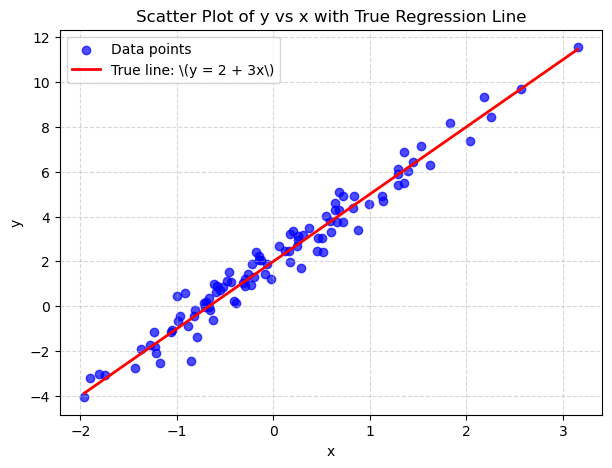

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# (a) Khởi tạo generator và mô phỏng x, epsilon
rng = np.random.default_rng(2026)
n = 100
x = rng.standard_normal(n)
eps = rng.normal(loc=0, scale=0.5, size=n)

# (b) Tính y và hệ số tương quan
y = 2 + 3 * x + eps
corr = np.corrcoef(x, y)
print("Correlation matrix:\n", corr)
print(f"Correlation coefficient between x and y: {corr[0, 1]:.4f}")

# (c) Vẽ đồ thị Scatter plot và lưu hình
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, color='blue', alpha=0.7, label='Data points')

# Đường lý thuyết y = 2 + 3x
x_line = np.linspace(x.min(), x.max(), 100)
y_line = 2 + 3 * x_line
ax.plot(x_line, y_line, color='red', linewidth=2, label='True line: \(y = 2 + 3x\)')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Scatter Plot of y vs x with True Regression Line')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

fig.savefig("ex2_scatter.png", dpi=150)
plt.show()

Exercise 3 – Cleaning the Auto data

In [4]:
import pandas as pd
import numpy as np
import os, urllib.request

# Kiểm tra nếu chưa có file Auto.data thì tự động tải về
fname = "Auto.data"
if not os.path.exists(fname):
    url = "https://raw.githubusercontent.com/intro-stat-learning/ISLP_labs/v2.2.3/Auto.data"
    urllib.request.urlretrieve(url, fname)

# (a) Đọc file Auto.data
Auto_raw = pd.read_csv(fname, sep=r"\s+", na_values=['?'])
n_missing = Auto_raw.isna().any(axis=1).sum()
print(f"Number of rows with missing values: {n_missing}")

Auto_clean = Auto_raw.dropna().copy()
print(f"Shape after dropna: {Auto_clean.shape}")

Number of rows with missing values: 5
Shape after dropna: (392, 9)


In [5]:
import pandas as pd
import numpy as np

# (a) Đọc file Auto.data, xử lý '?' thành NA và xoá các dòng khuyết
Auto_raw = pd.read_csv("Auto.data", sep=r"\s+", na_values=['?'])
n_missing = Auto_raw.isna().any(axis=1).sum()
print(f"Number of rows with missing values: {n_missing}")

Auto_clean = Auto_raw.dropna().copy()
print(f"Shape after dropna: {Auto_clean.shape}")

# (b) Phân loại biến & Map origin thành định danh định tính
# origin: 1 -> America, 2 -> Europe, 3 -> Japan
origin_map = {1: "America", 2: "Europe", 3: "Japan"}
Auto_clean['origin'] = Auto_clean['origin'].map(origin_map).astype('category')
Auto_clean['cylinders'] = Auto_clean['cylinders'].astype('category')

# (c) Báo cáo Range, Mean, Std cho các biến định lượng
quant_cols = ["mpg", "displacement", "horsepower", "weight", "acceleration", "year"]
stats = Auto_clean[quant_cols].agg(["min", "max", "mean", "std"]).T
stats['range'] = stats['max'] - stats['min']
print("\nQuantitative Variables Summary:")
print(stats[['range', 'mean', 'std']])

Number of rows with missing values: 5
Shape after dropna: (392, 9)

Quantitative Variables Summary:
               range         mean         std
mpg             37.6    23.445918    7.805007
displacement   387.0   194.411990  104.644004
horsepower     184.0   104.469388   38.491160
weight        3527.0  2977.584184  849.402560
acceleration    16.8    15.541327    2.758864
year            12.0    75.979592    3.683737


Exercise 4 – Subsetting rows with iloc[]

In [6]:
import numpy as np
import pandas as pd

# Loại bỏ các quan sát từ vị trí thứ 10 đến 85 (chỉ số 1-based -> chỉ số 0-based từ 9 đến 84)
keep_indices = np.r_[0:9, 85:len(Auto_clean)]
Auto_sub = Auto_clean.iloc[keep_indices]

# Tính lại thống kê cho tập con
quant_cols = ["mpg", "displacement", "horsepower", "weight", "acceleration", "year"]
sub_stats = Auto_sub[quant_cols].agg(["min", "max", "mean", "std"]).T
sub_stats['range'] = sub_stats['max'] - sub_stats['min']

print("Subset Summary Statistics:")
print(sub_stats[['range', 'mean', 'std']])

# So sánh sự thay đổi trung bình
print("\nMean Difference (Subset - Full):")
print(Auto_sub[quant_cols].mean() - Auto_clean[quant_cols].mean())

Subset Summary Statistics:
               range         mean         std
mpg             35.6    24.404430    7.867283
displacement   387.0   187.240506   99.678367
horsepower     184.0   100.721519   35.708853
weight        3348.0  2935.971519  811.300208
acceleration    16.3    15.726899    2.693721
year            12.0    77.145570    3.106217

Mean Difference (Subset - Full):
mpg              0.958512
displacement    -7.171483
horsepower      -3.747869
weight         -41.612665
acceleration     0.185572
year             1.165978
dtype: float64


Exercise 5 – Graphical exploration

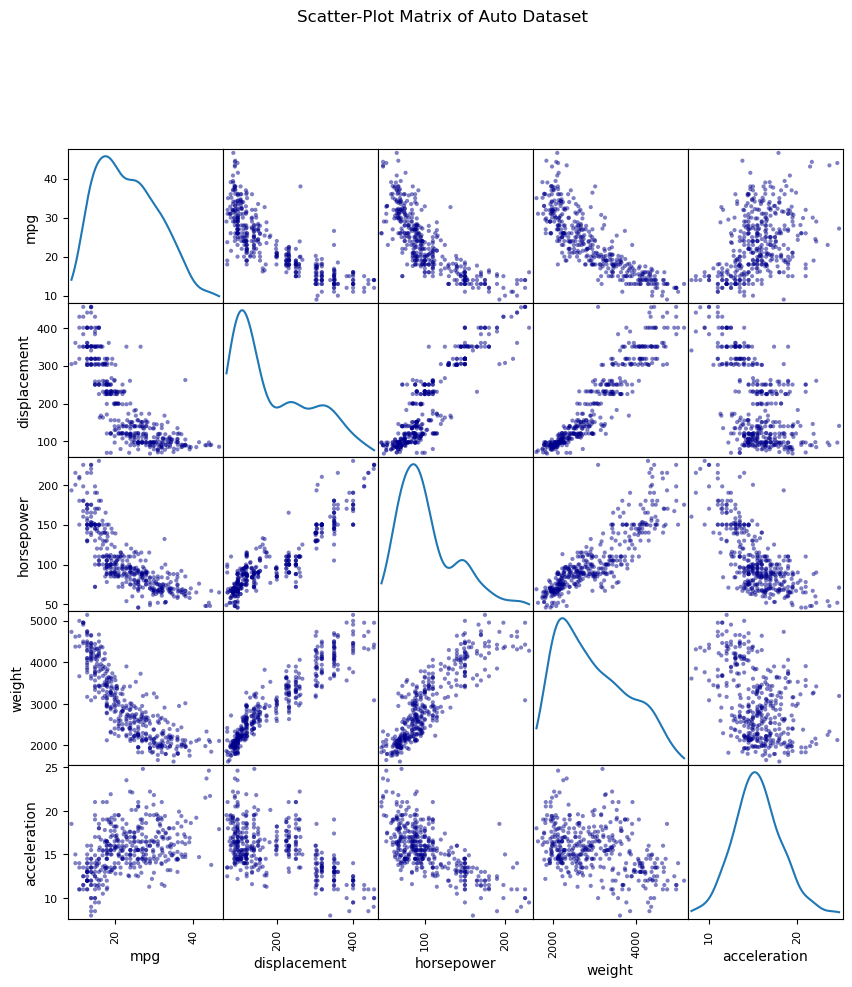

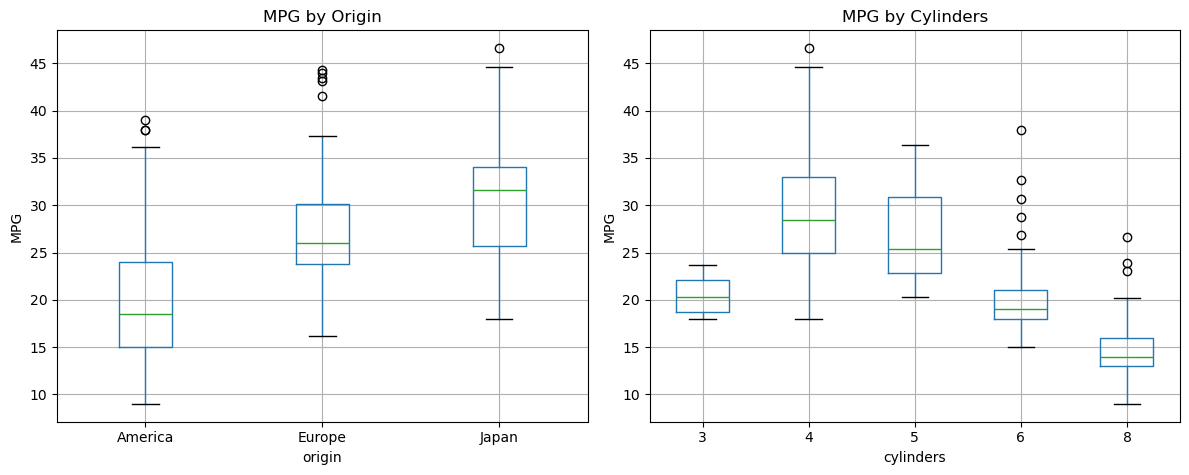

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# (a) Ma trận đồ thị phân tán (Scatter-plot matrix)
quant_subset = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
pd.plotting.scatter_matrix(Auto_clean[quant_subset], figsize=(10, 10), diagonal='kde', color='darkblue')
plt.suptitle("Scatter-Plot Matrix of Auto Dataset", y=1.02)
plt.show()

# (b) Box plots song song cho mpg theo origin và cylinders
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
Auto_clean.boxplot(column='mpg', by='origin', ax=axes[0])
axes[0].set_title('MPG by Origin')
axes[0].set_ylabel('MPG')

Auto_clean.boxplot(column='mpg', by='cylinders', ax=axes[1])
axes[1].set_title('MPG by Cylinders')
axes[1].set_ylabel('MPG')

plt.suptitle("") # Xóa tiêu đề tự động của pandas
plt.tight_layout()
plt.show()

Exercise 6 – The College data set

First 5 rows:
   Private  Apps  Accept  Enroll  Top10perc  Top25perc  F.Undergrad  \
0     Yes  1660    1232     721         23         52         2885   
1     Yes  2186    1924     512         16         29         2683   
2     Yes  1428    1097     336         22         50         1036   
3     Yes   417     349     137         60         89          510   
4     Yes   193     146      55         16         44          249   

   P.Undergrad  Outstate  Room.Board  Books  Personal  PhD  Terminal  \
0          537      7440        3300    450      2200   70        78   
1         1227     12280        6450    750      1500   29        30   
2           99     11250        3750    400      1165   53        66   
3           63     12960        5450    450       875   92        97   
4          869      7560        4120    800      1500   76        72   

   S.F.Ratio  perc.alumni  Expend  Grad.Rate  
0       18.1           12    7041         60  
1       12.2           16   10527    

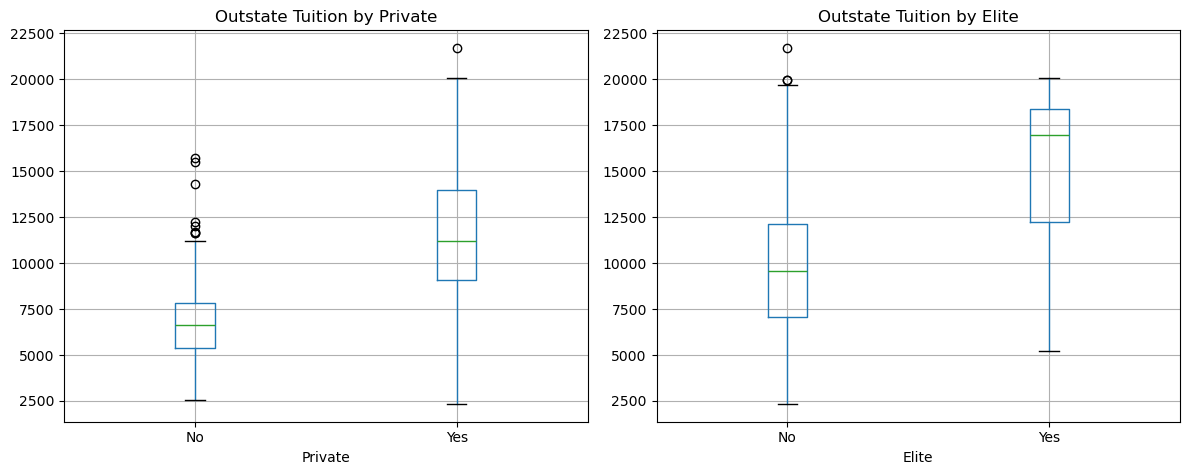

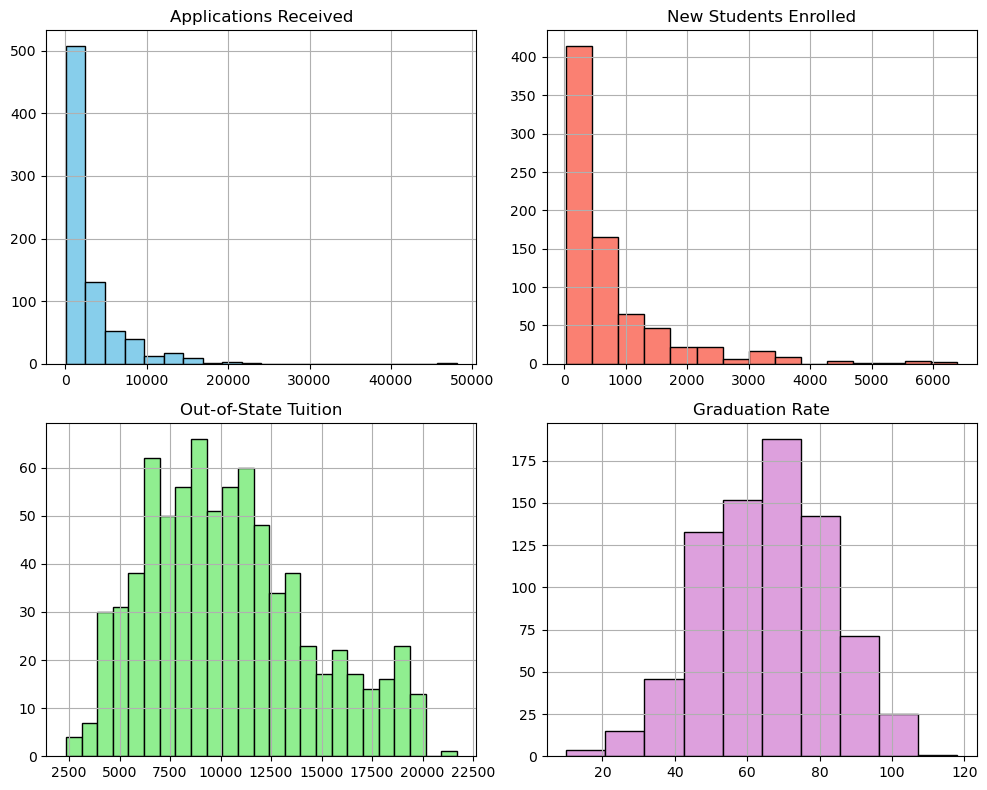

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from ISLP import load_data

# (a) Tải dữ liệu College và xem thông tin cơ bản
College = load_data("College")
print("First 5 rows:\n", College.head())
print("\nData Summary:\n", College.describe())

# (b) Số lượng trường tư thục (Private)
private_count = (College['Private'] == 'Yes').sum()
print(f"\nNumber of Private Colleges: {private_count}")

# (c) Tạo biến Elite (Top10perc > 50)
College['Elite'] = pd.Series(np.where(College['Top10perc'] > 50, "Yes", "No"), index=College.index).astype('category')
elite_count = (College['Elite'] == 'Yes').sum()
print(f"Number of Elite Colleges: {elite_count}")

# (d) Boxplots cho Outstate theo Private và Elite
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
College.boxplot(column='Outstate', by='Private', ax=axes[0])
axes[0].set_title('Outstate Tuition by Private')

College.boxplot(column='Outstate', by='Elite', ax=axes[1])
axes[1].set_title('Outstate Tuition by Elite')

plt.suptitle("")
plt.tight_layout()
plt.show()

# (e) Lưới 2x2 biểu đồ tần suất (Histograms)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
College['Apps'].hist(ax=axes[0, 0], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Applications Received')

College['Enroll'].hist(ax=axes[0, 1], bins=15, color='salmon', edgecolor='black')
axes[0, 1].set_title('New Students Enrolled')

College['Outstate'].hist(ax=axes[1, 0], bins=25, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Out-of-State Tuition')

College['Grad.Rate'].hist(ax=axes[1, 1], bins=10, color='plum', edgecolor='black')
axes[1, 1].set_title('Graduation Rate')

plt.tight_layout()
plt.show()

xercise 7 – Loops and string formatting

In [9]:
quant_cols = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "year"]

for col in quant_cols:
    # Ep kiểu số trong trường hợp cylinders vẫn đang dạng categorical
    vals = Auto_clean[col].astype(float)
    mean_val = vals.mean()
    std_val = vals.std()
    above_mean_share = (vals > mean_val).mean()
    
    print(f"{col:<14} mean = {mean_val:8.2f}  sd = {std_val:8.2f}  above-mean share = {above_mean_share:5.1%}")

mpg            mean =    23.45  sd =     7.81  above-mean share = 47.4%
cylinders      mean =     5.47  sd =     1.71  above-mean share = 47.4%
displacement   mean =   194.41  sd =   104.64  above-mean share = 43.4%
horsepower     mean =   104.47  sd =    38.49  above-mean share = 37.8%
weight         mean =  2977.58  sd =   849.40  above-mean share = 43.4%
acceleration   mean =    15.54  sd =     2.76  above-mean share = 45.7%
year           mean =    75.98  sd =     3.68  above-mean share = 54.1%


Exercise 8 – Estimating bias and variance by simulation (Optional)

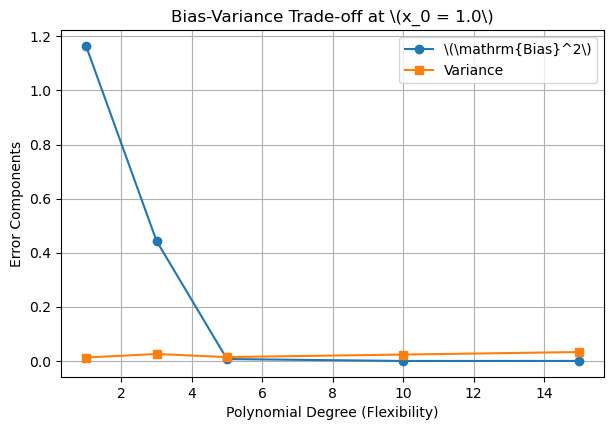

In [10]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(171)
f = lambda x: np.sin(2 * x) + 0.5 * x
x0 = 1.0
f_x0 = f(x0)
n_train = 60
sigma = 0.4
n_rep = 200

degrees = [1, 3, 5, 10, 15]
results = {}

for d in degrees:
    preds = []
    for r in range(n_rep):
        x_tr = rng.uniform(-3, 3, n_train)
        y_tr = f(x_tr) + rng.normal(0, sigma, n_train)
        
        # Fit đa thức bậc d
        coef = np.polyfit(x_tr, y_tr, deg=d)
        pred_x0 = np.polyval(coef, x0)
        preds.append(pred_x0)
    
    preds = np.array(preds)
    bias2 = (np.mean(preds) - f_x0)**2
    variance = np.var(preds)
    results[d] = (bias2, variance)

# Vẽ đồ thị
degrees_list = list(results.keys())
bias2_vals = [results[d][0] for d in degrees_list]
var_vals = [results[d][1] for d in degrees_list]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(degrees_list, bias2_vals, 'o-', label=r'\(\mathrm{Bias}^2\)')
ax.plot(degrees_list, var_vals, 's-', label=r'Variance')
ax.set_xlabel('Polynomial Degree (Flexibility)')
ax.set_ylabel('Error Components')
ax.set_title(f'Bias-Variance Trade-off at \(x_0 = {x0}\)')
ax.legend()
ax.grid(True)
plt.show()

Exercise 9 – Choosing $K$ for KNN (Optional)

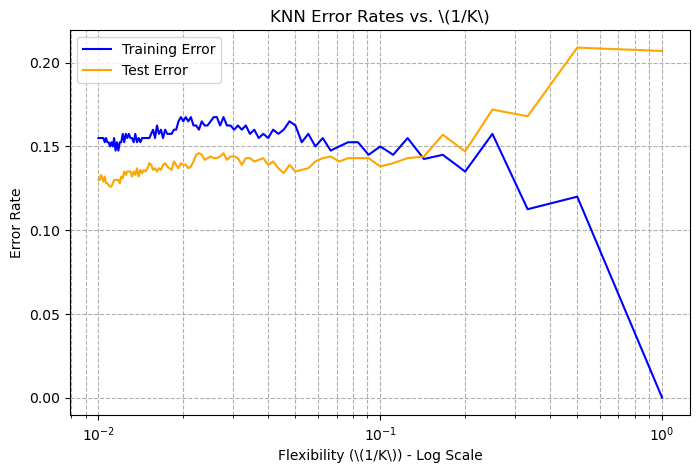

Minimum test error achieved at K = 90 (Test Error Rate = 0.126)


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Sử dụng dữ liệu mô phỏng từ Worked Example 2
rng = np.random.default_rng(2)
n = 200
X_tr = np.vstack([rng.normal([0, 0], 1, (n, 2)), rng.normal([1.5, 1.5], 1, (n, 2))])
y_tr = np.repeat([0, 1], n)
X_te = np.vstack([rng.normal([0, 0], 1, (500, 2)), rng.normal([1.5, 1.5], 1, (500, 2))])
y_te = np.repeat([0, 1], 500)

def knn_predict(X_train, y_train, X_new, K):
    d2 = ((X_new[:, None, :] - X_train[None, :, :])**2).sum(axis=2)
    nearest = np.argsort(d2, axis=1)[:, :K]
    return (y_train[nearest].mean(axis=1) > 0.5).astype(int)

Ks = range(1, 101)
train_err, test_err = [], []

for K in Ks:
    tr_pred = knn_predict(X_tr, y_tr, X_tr, K)
    te_pred = knn_predict(X_tr, y_tr, X_te, K)
    train_err.append(np.mean(tr_pred != y_tr))
    test_err.append(np.mean(te_pred != y_te))

inv_K = [1/K for K in Ks]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(inv_K, train_err, label='Training Error', color='blue')
ax.plot(inv_K, test_err, label='Test Error', color='orange')
ax.set_xscale('log')
ax.set_xlabel('Flexibility (\(1/K\)) - Log Scale')
ax.set_ylabel('Error Rate')
ax.set_title('KNN Error Rates vs. \(1/K\)')
ax.legend()
ax.grid(True, which="both", ls="--")
plt.show()

best_K = list(Ks)[np.argmin(test_err)]
print(f"Minimum test error achieved at K = {best_K} (Test Error Rate = {min(test_err):.3f})")